# Flight Delay Prediction — Model Comparison & Error Analysis

Results produced by `python -m src.train` (six-model comparison) and `python -m src.tune`
(randomized hyperparameter search + final XGBoost). This notebook reads those outputs and digs into
where the tuned model succeeds and fails.

**Setup recap**
- Train: Jan–Apr 2023 · Validation (threshold & tuning): May 2023 · Test: **June 2023**, never touched during development.
- Prediction point: the moment the flight pushes back from the gate (actual departure delay is known).
- Target: arrival delay ≥ 15 minutes.

In [1]:
import sys, json
sys.path.append('..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Image, display
from sklearn.calibration import calibration_curve

from src import plot_style as ps
from src.config import FIGURES_DIR, MODELS_DIR, REPORTS_DIR, TARGET
from src.dataset import load_splits
from src.evaluate import compute_metrics

ps.apply()
pd.set_option('display.precision', 4)

## 1. Six-model comparison (test set, June 2023)

In [2]:
cmp = pd.read_csv(REPORTS_DIR / 'model_comparison_departure.csv', index_col='model')
cmp[['accuracy', 'roc_auc', 'f1_macro', 'f1', 'f1_weighted', 'precision', 'recall', 'pr_auc', 'train_rows', 'fit_seconds']] \
    .sort_values('roc_auc', ascending=False)

,accuracy,roc_auc,f1_macro,f1,f1_weighted,precision,recall,pr_auc,train_rows,fit_seconds
model,,,,,,,,,,
Gradient Boosting,0.9068,0.9416,0.8837,0.8318,0.9051,0.8830,0.7861,0.9160,400000,56.6
XGBoost,0.9065,0.9410,0.8833,0.8313,0.9049,0.8819,0.7863,0.9156,400000,64.0
Random Forest,0.9056,0.9384,0.8822,0.8295,0.9039,0.8813,0.7835,0.9111,400000,163.1
Logistic Regression,0.9027,0.9310,0.8786,0.8246,0.9010,0.8737,0.7808,0.9052,400000,34.0
Decision Tree,0.9036,0.9294,0.8793,0.8252,0.9017,0.8805,0.7765,0.9035,400000,26.8
SVM (RBF),0.8947,0.9243,0.8712,0.8162,0.8940,0.8358,0.7975,0.8903,30000,81.6


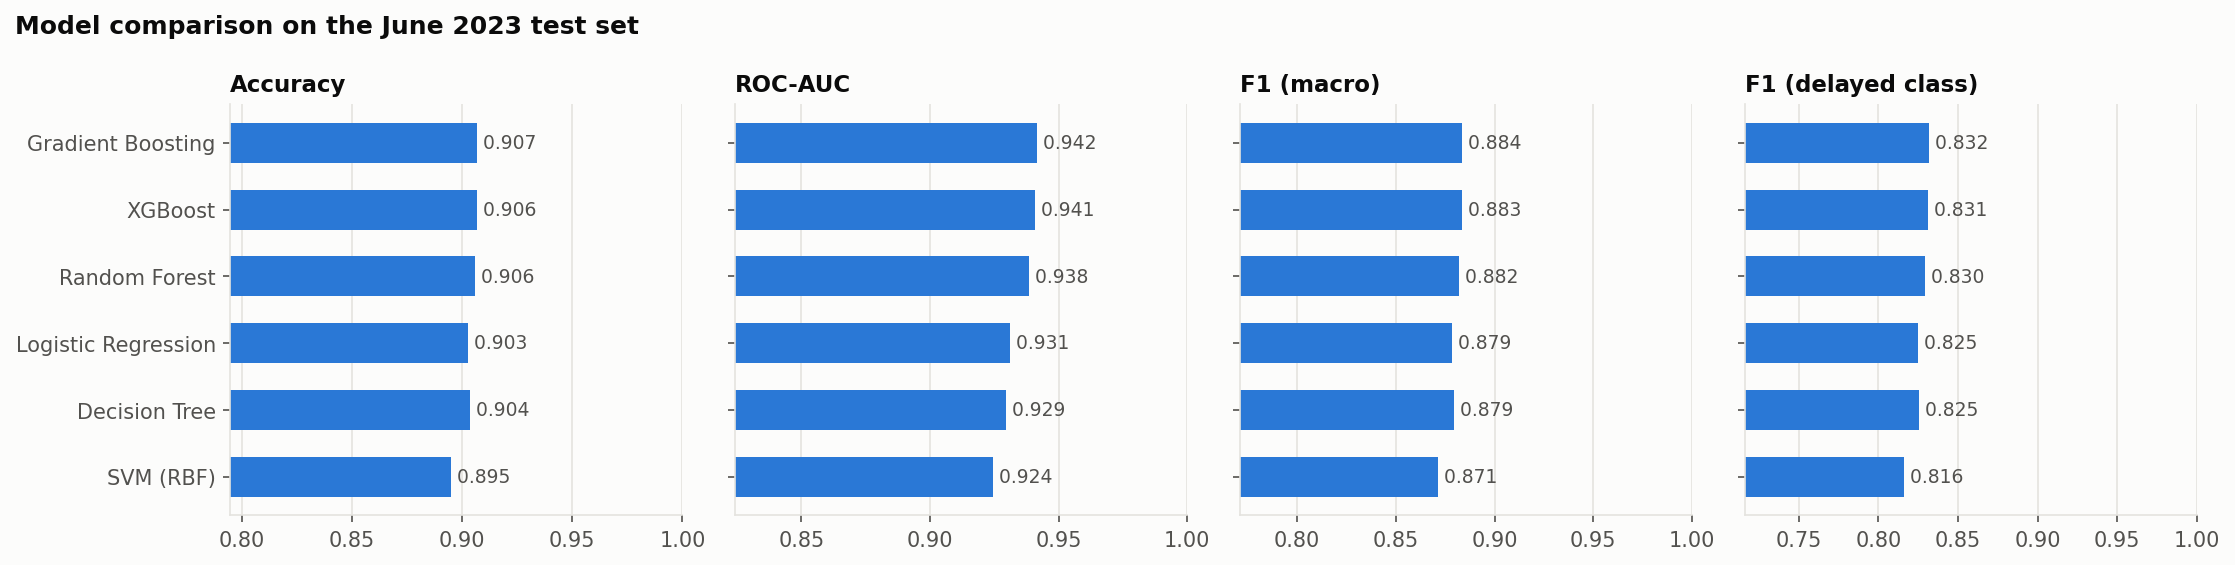

In [3]:
display(Image(FIGURES_DIR / 'model_comparison_departure.png'))

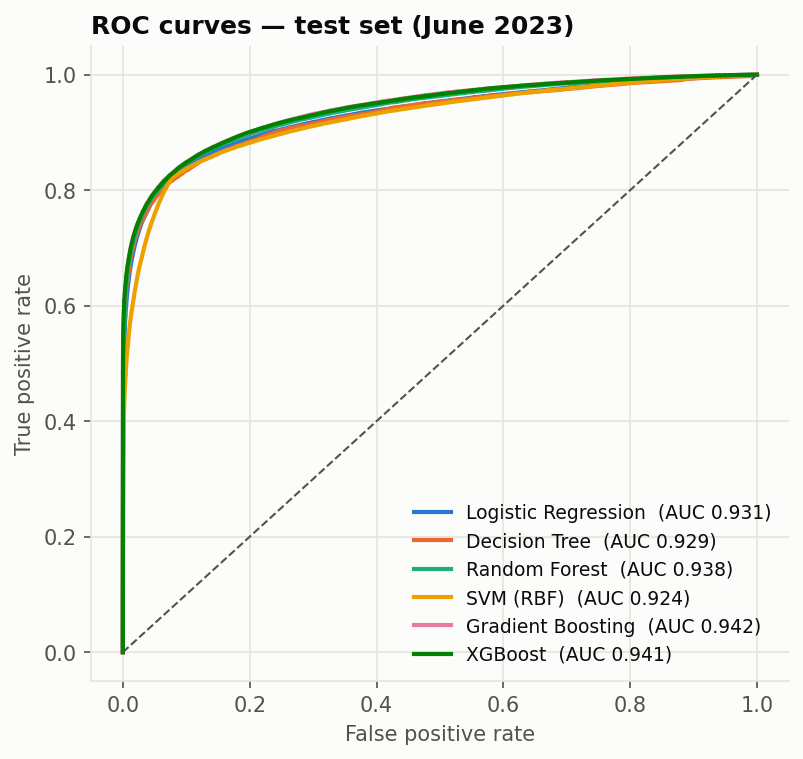

In [4]:
display(Image(FIGURES_DIR / 'roc_curves_departure.png'))

- The boosted-tree models (sklearn Gradient Boosting, XGBoost) lead on every metric, followed by Random Forest.
- Logistic Regression is surprisingly close: departure delay is a strong, nearly monotonic signal.
  The tree ensembles earn their gain on the uncertain 5–30 minute departure-delay band, where interactions
  with route padding, destination congestion and weather matter.
- The RBF SVM is the weakest and most expensive: kernel SVMs scale quadratically, so it could only be trained
  on a 30k-row sample.

## 2. Hyperparameter tuning

In [5]:
tuning = pd.read_csv(REPORTS_DIR / 'tuning_results_departure.csv')
print(f'{len(tuning)} configurations evaluated (ROC-AUC on May validation sample)')
tuning.head(10)

30 configurations evaluated (ROC-AUC on May validation sample)


,param_colsample_bytree,param_gamma,param_learning_rate,param_max_cat_to_onehot,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,mean_test_score,mean_fit_time
0,0.4099,2.5605,0.0369,8,10,33,839,0.0823,8.4644,0.8703,0.9403,93.8967
1,0.4189,3.1820,0.0469,8,7,30,684,0.0084,0.8796,0.9022,0.9397,52.0759
2,0.5373,0.3849,0.0438,8,7,2,881,0.9755,2.8674,0.9486,0.9393,75.9586
3,0.6026,4.7146,0.0480,8,11,12,709,0.3764,4.3547,0.6592,0.9384,73.4086
4,0.4447,4.9344,0.1619,8,11,24,262,1.0384,4.2316,0.8916,0.9376,20.3557
5,0.4609,3.3175,0.0203,8,9,18,362,0.2580,0.3281,0.8849,0.9375,47.6171
6,0.6687,2.7645,0.0996,1,6,17,493,0.0229,2.8507,0.8534,0.9373,36.0257
7,0.5040,1.9553,0.0328,8,5,6,765,0.1053,0.2663,0.9878,0.9370,49.0985
8,0.6206,1.3260,0.0387,8,9,8,482,0.0404,0.6391,0.8580,0.9369,51.8251
9,0.6820,1.3978,0.2188,8,4,37,479,0.0167,1.8704,0.8289,0.9363,26.9104


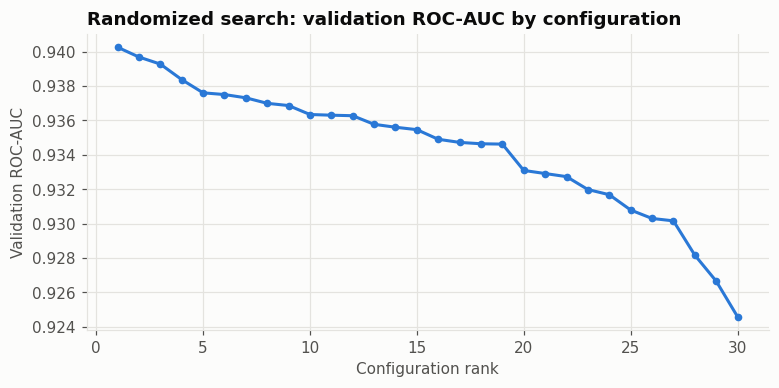

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
scores = tuning['mean_test_score'].values
ax.plot(np.arange(1, len(scores) + 1), np.sort(scores)[::-1], marker='o', ms=4, color=ps.BLUE)
ax.set_xlabel('Configuration rank')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('Randomized search: validation ROC-AUC by configuration')
fig.savefig(FIGURES_DIR / 'tuning_scores.png')

In [7]:
final = json.load(open(REPORTS_DIR / 'final_metrics_departure.json'))
print('Best params:', json.dumps(final['best_params'], indent=2))
print('Trees after early stopping:', final['best_iteration'] + 1)
summary = pd.DataFrame({
    'XGBoost (default, 400k rows)': cmp.loc['XGBoost'],
    'XGBoost (tuned, full train)': pd.Series(final['test']),
}).loc[['accuracy', 'roc_auc', 'f1_macro', 'f1', 'f1_weighted', 'precision', 'recall', 'pr_auc', 'threshold']]
summary

Best params: {
  "colsample_bytree": 0.4099526973567137,
  "gamma": 2.560465291496405,
  "learning_rate": 0.03693258423995022,
  "max_cat_to_onehot": 8,
  "max_depth": 10,
  "min_child_weight": 33,
  "n_estimators": 839,
  "reg_alpha": 0.08225204705637795,
  "reg_lambda": 8.464398106421378,
  "subsample": 0.8702760468157122
}
Trees after early stopping: 1010


,"XGBoost (default, 400k rows)","XGBoost (tuned, full train)"
accuracy,0.9065,0.9082
roc_auc,0.9410,0.9432
f1_macro,0.8833,0.8849
f1,0.8313,0.8332
f1_weighted,0.9049,0.9063
precision,0.8819,0.8909
recall,0.7863,0.7825
pr_auc,0.9156,0.9177
threshold,0.4480,0.4468


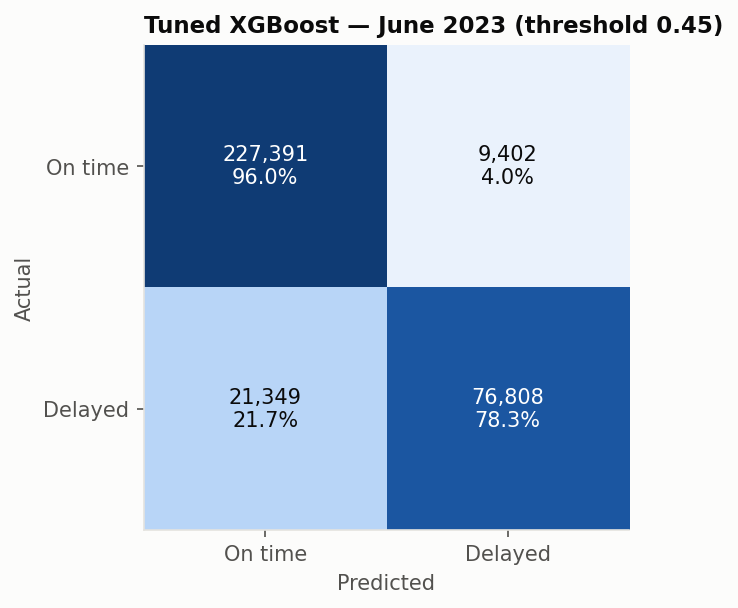

In [8]:
display(Image(FIGURES_DIR / 'confusion_matrix_departure.png'))

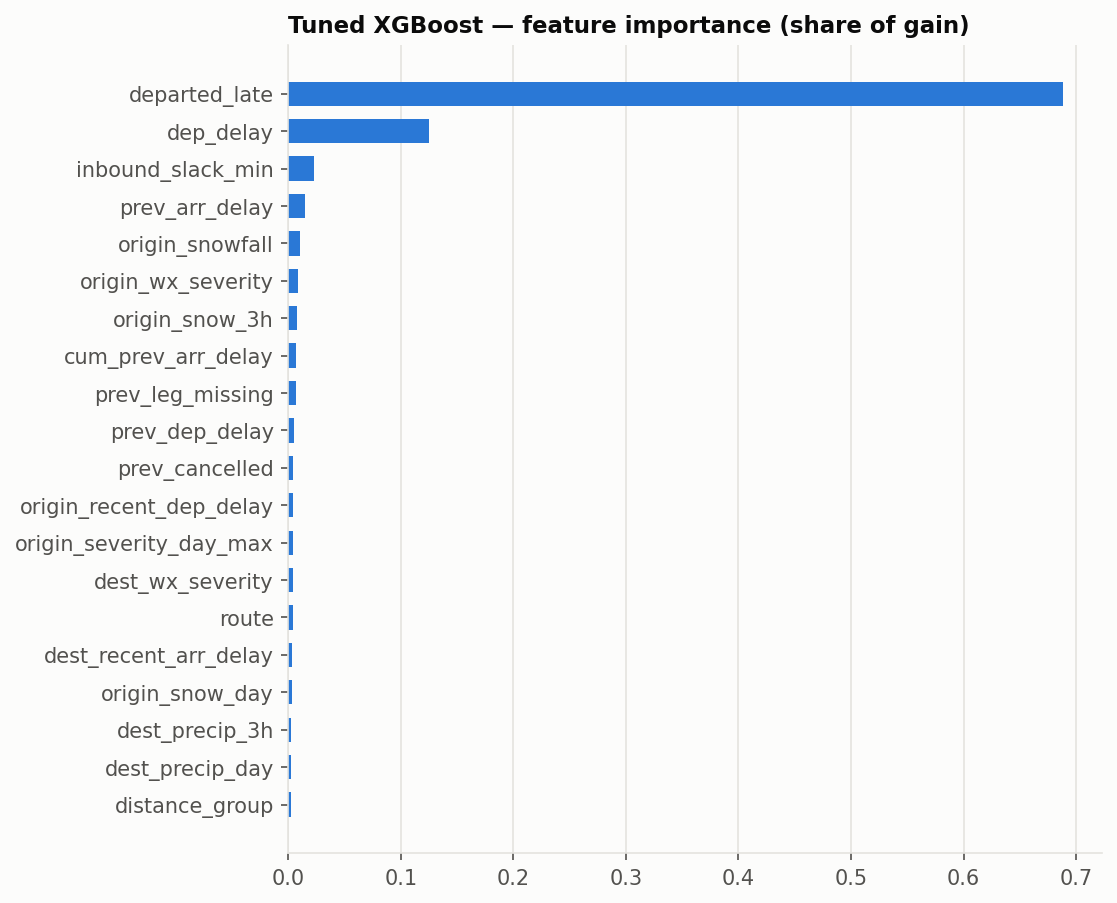

In [9]:
display(Image(FIGURES_DIR / 'feature_importance_departure.png'))

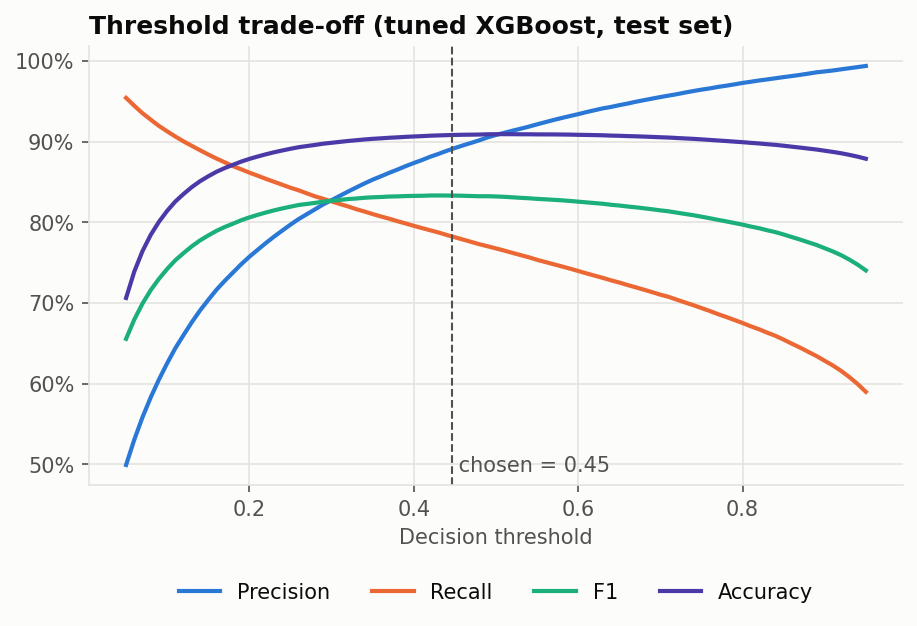

In [10]:
display(Image(FIGURES_DIR / 'threshold_tradeoff_departure.png'))

## 3. Error analysis on the test month

In [11]:
bundle = joblib.load(MODELS_DIR / 'xgboost_tuned_departure.joblib')
model, features, thr = bundle['model'], bundle['features'], bundle['threshold']
_, _, test, _ = load_splits('departure')
p = model.predict_proba(test.X)[:, 1]
t = test.X.assign(y=test.y.values, p=p, pred=(p >= thr).astype(int))
t['correct'] = (t['y'] == t['pred']).astype(int)
print(f'threshold = {thr:.3f}')

threshold = 0.447


### 3.1 Accuracy by departure-delay band

,flights,delay_rate,accuracy
dep_delay,,,
≤0,168970,0.0481,0.9513
0–10,54660,0.1183,0.8783
10–20,28334,0.3073,0.7006
20–30,18199,0.6474,0.6844
30–45,17590,0.9118,0.9154
>45,47197,0.9967,0.9966


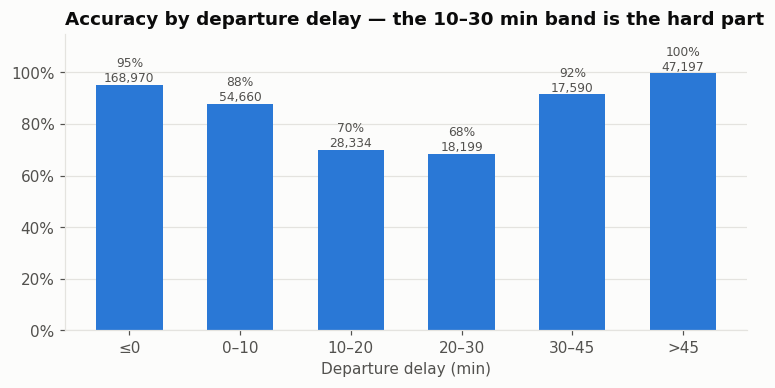

In [12]:
band = pd.cut(t['dep_delay'], [-100, 0, 10, 20, 30, 45, 5000],
              labels=['≤0', '0–10', '10–20', '20–30', '30–45', '>45'])
g = t.groupby(band, observed=True).agg(flights=('y', 'size'), delay_rate=('y', 'mean'), accuracy=('correct', 'mean'))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(g.index.astype(str), g['accuracy'], color=ps.BLUE, width=0.6)
for i, (a, n) in enumerate(zip(g['accuracy'], g['flights'])):
    ax.text(i, a, f'{a:.0%}\n{n:,}', ha='center', va='bottom', fontsize=8, color=ps.TEXT_MUTED)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='x', visible=False)
ax.set_xlabel('Departure delay (min)')
ax.set_title('Accuracy by departure delay — the 10–30 min band is the hard part')
fig.savefig(FIGURES_DIR / 'accuracy_by_dep_delay.png')
g

Errors concentrate where the outcome is genuinely uncertain: flights leaving 10–30 minutes late, which may or
may not recover the time en route. Flights that leave on time or very late are easy.

### 3.2 Hard band only: does feature engineering help beyond departure delay?

In [13]:
hard = t[(t['dep_delay'] >= 10) & (t['dep_delay'] < 30)]
naive = (hard['dep_delay'] >= 15).astype(int)   # rule: 'late departure => late arrival'
from sklearn.metrics import accuracy_score, roc_auc_score
print(f"flights in 10–30 min band: {len(hard):,}")
print(f"rule 'dep_delay >= 15'   accuracy: {accuracy_score(hard['y'], naive):.3f}")
print(f"tuned XGBoost            accuracy: {accuracy_score(hard['y'], hard['pred']):.3f}"
      f"   ROC-AUC: {roc_auc_score(hard['y'], hard['p']):.3f}")

flights in 10–30 min band: 48,872
rule 'dep_delay >= 15'   accuracy: 0.602
tuned XGBoost            accuracy: 0.700   ROC-AUC: 0.756


### 3.3 Daily performance across June

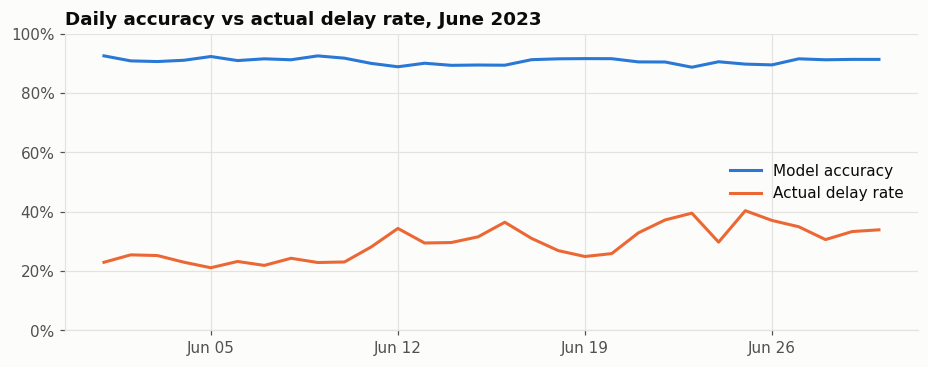

In [14]:
dates = pd.read_parquet('../data/processed/features.parquet', columns=['flight_date', 'month'])
t['flight_date'] = dates.loc[dates['month'] == 6, 'flight_date'].values
daily = t.groupby('flight_date').agg(accuracy=('correct', 'mean'), delay_rate=('y', 'mean'))
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily.index, daily['accuracy'], color=ps.BLUE, label='Model accuracy')
ax.plot(daily.index, daily['delay_rate'], color=ps.ORANGE, label='Actual delay rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.legend(loc='center right', ncol=1)
ax.set_ylim(0, 1)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_title('Daily accuracy vs actual delay rate, June 2023')
fig.savefig(FIGURES_DIR / 'daily_accuracy_june.png')

### 3.4 Calibration

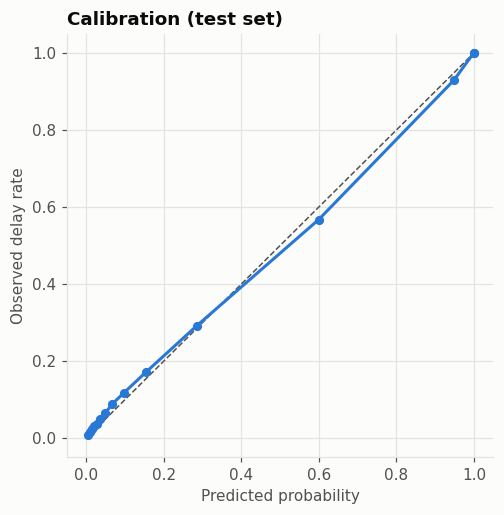

In [15]:
frac_pos, mean_pred = calibration_curve(t['y'], t['p'], n_bins=15, strategy='quantile')
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls='--', color=ps.TEXT_MUTED, lw=1)
ax.plot(mean_pred, frac_pos, marker='o', ms=5, color=ps.BLUE)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed delay rate')
ax.set_title('Calibration (test set)')
fig.savefig(FIGURES_DIR / 'calibration_departure.png')

Overall the probabilities are close to calibrated: the mean predicted probability on June is 0.287 against an
actual delay rate of 0.293. In the low-probability bins the model slightly under-predicts (e.g. predicted ≈0.09,
observed ≈0.11), consistent with June's base rate (29%) being higher than the training months (23%). Delay base
rates drift seasonally, so a production model would need periodic retraining or recalibration.

## 4. Harder variant: pre-departure prediction

In [16]:
pre_path = REPORTS_DIR / 'final_metrics_pre_departure.json'
pre_cmp = pd.read_csv(REPORTS_DIR / 'model_comparison_pre_departure.csv', index_col='model')
pre = json.load(open(pre_path))
pd.DataFrame({
    'At departure (tuned XGBoost)': pd.Series(final['test']),
    'Pre-departure (tuned XGBoost)': pd.Series(pre['test']),
}).loc[['accuracy', 'roc_auc', 'f1_macro', 'f1', 'precision', 'recall']]

,At departure (tuned XGBoost),Pre-departure (tuned XGBoost)
accuracy,0.9082,0.8074
roc_auc,0.9432,0.8369
f1_macro,0.8849,0.7626
f1,0.8332,0.6595
precision,0.8909,0.6843
recall,0.7825,0.6365


In [17]:
pre_cmp[['accuracy', 'roc_auc', 'f1_macro', 'f1']].sort_values('roc_auc', ascending=False)

,accuracy,roc_auc,f1_macro,f1
model,,,,
Gradient Boosting,0.8028,0.8331,0.7589,0.6560
XGBoost,0.8067,0.8292,0.7594,0.6527
Random Forest,0.7764,0.8230,0.7387,0.6394
Decision Tree,0.7818,0.7961,0.7316,0.6155
Logistic Regression,0.7529,0.7863,0.7110,0.6010
SVM (RBF),0.7649,0.7785,0.7212,0.6108


Without the flight's own departure delay, the task is substantially harder. The engineered features
(inbound aircraft delay, airport state, weather) still carry it to a useful ROC-AUC, which is what makes the
at-departure model robust in the uncertain band.